## COL taxonomy plots - kingdom

In [1]:
#load libraries
library(tidyverse)
library(vegan)
library(phyloseq)
library(ggplot2)
library(RColorBrewer)
library(DESeq2)
library(dplyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following obj

In [2]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/kraken_bracken")

In [48]:
taxa = read.csv('otu_id_kingdom.csv',header=TRUE)
head(taxa)

,taxonomy_id,name,taxonomy_lvl
,<int>,<chr>,<chr>
1,3379134,Pseudomonadati,K
2,1783272,Bacillati,K
3,4751,Fungi,K
4,3366610,Methanobacteriati,K
5,3384189,Fusobacteriati,K
6,1783275,Thermoproteati,K


In [49]:
# remove taxa level col
taxa$taxonomy_lvl <- NULL 
# change taxa table names
colnames(taxa) <- c("otuid","species")
head(taxa)

,otuid,species
,<int>,<chr>
1,3379134,Pseudomonadati
2,1783272,Bacillati
3,4751,Fungi
4,3366610,Methanobacteriati
5,3384189,Fusobacteriati
6,1783275,Thermoproteati


In [50]:
# make the index the otu ids
row.names(taxa) <- taxa$otuid
taxa$otuid <- NULL
head(taxa)

,species
,<chr>
3379134,Pseudomonadati
1783272,Bacillati
4751,Fungi
3366610,Methanobacteriati
3384189,Fusobacteriati
1783275,Thermoproteati


In [51]:
#convert to character matrix to create phyloseq objects 
taxonomy <- as.matrix(taxa)

# check structure
str(taxonomy) 

 chr [1:16, 1] "Pseudomonadati" "Bacillati" "Fungi" "Methanobacteriati" ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:16] "3379134" "1783272" "4751" "3366610" ...
  ..$ : chr "species"


In [52]:
#read in normalized otu table
otu = read.csv('otu_normtable_kingdom.csv',header=TRUE)
head(otu)

,X,X012025_COL_SAN_T5_568_OFAV_S1,X012025_COL_SAN_T5_569_DLAB_S2,X012025_COL_SAN_T5_570_DLAB_S3,X012025_COL_SAN_T5_571_DLAB_S4,X012025_COL_SAN_T5_572_OFAV_S5,X012025_COL_SAN_T5_573_PSTR_S6,X012025_COL_SAN_T5_574_MCAV_S7,X012025_COL_SAN_T5_575_DLAB_S8,X012025_COL_SAN_T5_576_PSTR_S9,⋯,X032024_COL_SAN_T5_154_PSTR_S38,X032024_COL_SAN_T5_158_DLAB_S15,X032024_COL_SAN_T5_159_DLAB_S16,X032024_COL_SAN_T5_160_DLAB_S41,X032024_COL_SAN_T5_161_DLAB_S42,X032024_COL_SAN_T5_162_PSTR_S39,X032024_COL_SAN_T5_163_PSTR_S11c,X032024_COL_SAN_T5_166_OFAV_S20,X032024_COL_SAN_T5_167_OFAV_S21,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3379134,571678.129,599277.54,696587.857,671595.090,568682.283,672321.447,548723.496,676091.343,581659.428,⋯,622867.755,546127.591,529415.952,588979.204,666563.031,659938.411,582615.430,591050.584,558054.002,32097234.5
2,1783272,336918.580,321621.62,254308.738,284173.917,337725.141,270150.504,352778.166,290323.638,331068.329,⋯,307592.490,356094.224,366301.644,330233.371,274625.351,276565.140,327495.320,324002.223,348566.955,19223006.1
3,4751,48351.953,34108.02,24586.792,21043.196,49870.387,28536.602,53217.543,14370.174,45902.295,⋯,32626.047,49366.861,53280.045,34327.529,28462.348,29684.368,48929.446,45341.857,49817.453,2385044.2
4,3366610,16639.706,12925.97,9863.756,9727.301,16880.779,11248.015,14263.055,9543.146,14688.033,⋯,15224.802,17948.806,15228.463,12193.334,11005.509,12475.238,14489.475,14991.662,15811.744,817194.8
5,3384189,7548.883,12773.64,4854.439,4101.976,7089.479,5219.451,8623.466,2364.361,7814.090,⋯,5520.063,9444.527,11246.072,9280.115,5365.199,6431.864,7758.526,7165.092,8341.150,462910.0
6,1783275,6123.614,11063.24,2768.434,2079.356,6225.394,4459.876,7395.883,1453.149,5807.509,⋯,4486.768,6566.450,9018.211,7839.984,4852.815,4980.048,5833.705,4702.613,6100.647,314424.4


In [53]:
# rename first col as kingdom
names(otu)[1] <- "species"
head(otu)
dim(otu)

,species,X012025_COL_SAN_T5_568_OFAV_S1,X012025_COL_SAN_T5_569_DLAB_S2,X012025_COL_SAN_T5_570_DLAB_S3,X012025_COL_SAN_T5_571_DLAB_S4,X012025_COL_SAN_T5_572_OFAV_S5,X012025_COL_SAN_T5_573_PSTR_S6,X012025_COL_SAN_T5_574_MCAV_S7,X012025_COL_SAN_T5_575_DLAB_S8,X012025_COL_SAN_T5_576_PSTR_S9,⋯,X032024_COL_SAN_T5_154_PSTR_S38,X032024_COL_SAN_T5_158_DLAB_S15,X032024_COL_SAN_T5_159_DLAB_S16,X032024_COL_SAN_T5_160_DLAB_S41,X032024_COL_SAN_T5_161_DLAB_S42,X032024_COL_SAN_T5_162_PSTR_S39,X032024_COL_SAN_T5_163_PSTR_S11c,X032024_COL_SAN_T5_166_OFAV_S20,X032024_COL_SAN_T5_167_OFAV_S21,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3379134,571678.129,599277.54,696587.857,671595.090,568682.283,672321.447,548723.496,676091.343,581659.428,⋯,622867.755,546127.591,529415.952,588979.204,666563.031,659938.411,582615.430,591050.584,558054.002,32097234.5
2,1783272,336918.580,321621.62,254308.738,284173.917,337725.141,270150.504,352778.166,290323.638,331068.329,⋯,307592.490,356094.224,366301.644,330233.371,274625.351,276565.140,327495.320,324002.223,348566.955,19223006.1
3,4751,48351.953,34108.02,24586.792,21043.196,49870.387,28536.602,53217.543,14370.174,45902.295,⋯,32626.047,49366.861,53280.045,34327.529,28462.348,29684.368,48929.446,45341.857,49817.453,2385044.2
4,3366610,16639.706,12925.97,9863.756,9727.301,16880.779,11248.015,14263.055,9543.146,14688.033,⋯,15224.802,17948.806,15228.463,12193.334,11005.509,12475.238,14489.475,14991.662,15811.744,817194.8
5,3384189,7548.883,12773.64,4854.439,4101.976,7089.479,5219.451,8623.466,2364.361,7814.090,⋯,5520.063,9444.527,11246.072,9280.115,5365.199,6431.864,7758.526,7165.092,8341.150,462910.0
6,1783275,6123.614,11063.24,2768.434,2079.356,6225.394,4459.876,7395.883,1453.149,5807.509,⋯,4486.768,6566.450,9018.211,7839.984,4852.815,4980.048,5833.705,4702.613,6100.647,314424.4


[1] 17 58

In [54]:
#remove X's from headers
names(otu) <- sub("^X", "", names(otu))
otu_table=as.data.frame(otu)
head(otu_table)

,species,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,⋯,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3379134,571678.129,599277.54,696587.857,671595.090,568682.283,672321.447,548723.496,676091.343,581659.428,⋯,622867.755,546127.591,529415.952,588979.204,666563.031,659938.411,582615.430,591050.584,558054.002,32097234.5
2,1783272,336918.580,321621.62,254308.738,284173.917,337725.141,270150.504,352778.166,290323.638,331068.329,⋯,307592.490,356094.224,366301.644,330233.371,274625.351,276565.140,327495.320,324002.223,348566.955,19223006.1
3,4751,48351.953,34108.02,24586.792,21043.196,49870.387,28536.602,53217.543,14370.174,45902.295,⋯,32626.047,49366.861,53280.045,34327.529,28462.348,29684.368,48929.446,45341.857,49817.453,2385044.2
4,3366610,16639.706,12925.97,9863.756,9727.301,16880.779,11248.015,14263.055,9543.146,14688.033,⋯,15224.802,17948.806,15228.463,12193.334,11005.509,12475.238,14489.475,14991.662,15811.744,817194.8
5,3384189,7548.883,12773.64,4854.439,4101.976,7089.479,5219.451,8623.466,2364.361,7814.090,⋯,5520.063,9444.527,11246.072,9280.115,5365.199,6431.864,7758.526,7165.092,8341.150,462910.0
6,1783275,6123.614,11063.24,2768.434,2079.356,6225.394,4459.876,7395.883,1453.149,5807.509,⋯,4486.768,6566.450,9018.211,7839.984,4852.815,4980.048,5833.705,4702.613,6100.647,314424.4


In [55]:
# make the index the otus
row.names(otu_table) <- otu_table$species
otu_table$species <- NULL
head(otu_table)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,⋯,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,Sum
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3379134,571678.129,599277.54,696587.857,671595.090,568682.283,672321.447,548723.496,676091.343,581659.428,555686.644,⋯,622867.755,546127.591,529415.952,588979.204,666563.031,659938.411,582615.430,591050.584,558054.002,32097234.5
1783272,336918.580,321621.62,254308.738,284173.917,337725.141,270150.504,352778.166,290323.638,331068.329,346920.799,⋯,307592.490,356094.224,366301.644,330233.371,274625.351,276565.140,327495.320,324002.223,348566.955,19223006.1
4751,48351.953,34108.02,24586.792,21043.196,49870.387,28536.602,53217.543,14370.174,45902.295,53159.890,⋯,32626.047,49366.861,53280.045,34327.529,28462.348,29684.368,48929.446,45341.857,49817.453,2385044.2
3366610,16639.706,12925.97,9863.756,9727.301,16880.779,11248.015,14263.055,9543.146,14688.033,15329.298,⋯,15224.802,17948.806,15228.463,12193.334,11005.509,12475.238,14489.475,14991.662,15811.744,817194.8
3384189,7548.883,12773.64,4854.439,4101.976,7089.479,5219.451,8623.466,2364.361,7814.090,8358.220,⋯,5520.063,9444.527,11246.072,9280.115,5365.199,6431.864,7758.526,7165.092,8341.150,462910.0
1783275,6123.614,11063.24,2768.434,2079.356,6225.394,4459.876,7395.883,1453.149,5807.509,8306.785,⋯,4486.768,6566.450,9018.211,7839.984,4852.815,4980.048,5833.705,4702.613,6100.647,314424.4


In [56]:
#remove Sum column
otu_table$Sum <- NULL
head(otu_table)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3379134,571678.129,599277.54,696587.857,671595.090,568682.283,672321.447,548723.496,676091.343,581659.428,555686.644,⋯,688293.136,622867.755,546127.591,529415.952,588979.204,666563.031,659938.411,582615.430,591050.584,558054.002
1783272,336918.580,321621.62,254308.738,284173.917,337725.141,270150.504,352778.166,290323.638,331068.329,346920.799,⋯,266457.670,307592.490,356094.224,366301.644,330233.371,274625.351,276565.140,327495.320,324002.223,348566.955
4751,48351.953,34108.02,24586.792,21043.196,49870.387,28536.602,53217.543,14370.174,45902.295,53159.890,⋯,20453.996,32626.047,49366.861,53280.045,34327.529,28462.348,29684.368,48929.446,45341.857,49817.453
3366610,16639.706,12925.97,9863.756,9727.301,16880.779,11248.015,14263.055,9543.146,14688.033,15329.298,⋯,9336.201,15224.802,17948.806,15228.463,12193.334,11005.509,12475.238,14489.475,14991.662,15811.744
3384189,7548.883,12773.64,4854.439,4101.976,7089.479,5219.451,8623.466,2364.361,7814.090,8358.220,⋯,5191.137,5520.063,9444.527,11246.072,9280.115,5365.199,6431.864,7758.526,7165.092,8341.150
1783275,6123.614,11063.24,2768.434,2079.356,6225.394,4459.876,7395.883,1453.149,5807.509,8306.785,⋯,2530.189,4486.768,6566.450,9018.211,7839.984,4852.815,4980.048,5833.705,4702.613,6100.647


In [57]:
# sort by most abundant OTUs
otus_sorted <- otu_table[order(rowSums(otu_table), decreasing = TRUE), ]
head(otus_sorted)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3379134,571678.129,599277.54,696587.857,671595.090,568682.283,672321.447,548723.496,676091.343,581659.43,555686.64,⋯,688293.136,622867.755,546127.591,529415.95,588979.204,666563.031,659938.411,582615.430,591050.584,558054.00
Total_reads,317133.000,229770.00,413230.000,352513.000,401581.000,666162.000,164551.000,793449.000,570124.00,622142.00,⋯,305906.000,291301.000,261633.000,280987.00,606889.000,977783.000,597183.000,928398.000,179900.000,148181.00
1783272,336918.580,321621.62,254308.738,284173.917,337725.141,270150.504,352778.166,290323.638,331068.33,346920.80,⋯,266457.670,307592.490,356094.224,366301.64,330233.371,274625.351,276565.140,327495.320,324002.223,348566.96
4751,48351.953,34108.02,24586.792,21043.196,49870.387,28536.602,53217.543,14370.174,45902.29,53159.89,⋯,20453.996,32626.047,49366.861,53280.04,34327.529,28462.348,29684.368,48929.446,45341.857,49817.45
3366610,16639.706,12925.97,9863.756,9727.301,16880.779,11248.015,14263.055,9543.146,14688.03,15329.30,⋯,9336.201,15224.802,17948.806,15228.46,12193.334,11005.509,12475.238,14489.475,14991.662,15811.74
3384189,7548.883,12773.64,4854.439,4101.976,7089.479,5219.451,8623.466,2364.361,7814.09,8358.22,⋯,5191.137,5520.063,9444.527,11246.07,9280.115,5365.199,6431.864,7758.526,7165.092,8341.15


In [58]:
#remove total reads row
otus_sorted <- otus_sorted[-2, ]
head(otus_sorted)
dim (otus_sorted)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3379134,571678.129,599277.54,696587.857,671595.090,568682.283,672321.447,548723.496,676091.343,581659.428,555686.644,⋯,688293.136,622867.755,546127.591,529415.952,588979.204,666563.031,659938.411,582615.430,591050.584,558054.002
1783272,336918.580,321621.62,254308.738,284173.917,337725.141,270150.504,352778.166,290323.638,331068.329,346920.799,⋯,266457.670,307592.490,356094.224,366301.644,330233.371,274625.351,276565.140,327495.320,324002.223,348566.955
4751,48351.953,34108.02,24586.792,21043.196,49870.387,28536.602,53217.543,14370.174,45902.295,53159.890,⋯,20453.996,32626.047,49366.861,53280.045,34327.529,28462.348,29684.368,48929.446,45341.857,49817.453
3366610,16639.706,12925.97,9863.756,9727.301,16880.779,11248.015,14263.055,9543.146,14688.033,15329.298,⋯,9336.201,15224.802,17948.806,15228.463,12193.334,11005.509,12475.238,14489.475,14991.662,15811.744
3384189,7548.883,12773.64,4854.439,4101.976,7089.479,5219.451,8623.466,2364.361,7814.090,8358.220,⋯,5191.137,5520.063,9444.527,11246.072,9280.115,5365.199,6431.864,7758.526,7165.092,8341.150
1783275,6123.614,11063.24,2768.434,2079.356,6225.394,4459.876,7395.883,1453.149,5807.509,8306.785,⋯,2530.189,4486.768,6566.450,9018.211,7839.984,4852.815,4980.048,5833.705,4702.613,6100.647


[1] 16 56

In [59]:
# Convert to matrix
otus=as.matrix(otus_sorted)
head(otus)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
3379134,571678.129,599277.54,696587.857,671595.090,568682.283,672321.447,548723.496,676091.343,581659.428,555686.644,⋯,688293.136,622867.755,546127.591,529415.952,588979.204,666563.031,659938.411,582615.430,591050.584,558054.002
1783272,336918.580,321621.62,254308.738,284173.917,337725.141,270150.504,352778.166,290323.638,331068.329,346920.799,⋯,266457.670,307592.490,356094.224,366301.644,330233.371,274625.351,276565.140,327495.320,324002.223,348566.955
4751,48351.953,34108.02,24586.792,21043.196,49870.387,28536.602,53217.543,14370.174,45902.295,53159.890,⋯,20453.996,32626.047,49366.861,53280.045,34327.529,28462.348,29684.368,48929.446,45341.857,49817.453
3366610,16639.706,12925.97,9863.756,9727.301,16880.779,11248.015,14263.055,9543.146,14688.033,15329.298,⋯,9336.201,15224.802,17948.806,15228.463,12193.334,11005.509,12475.238,14489.475,14991.662,15811.744
3384189,7548.883,12773.64,4854.439,4101.976,7089.479,5219.451,8623.466,2364.361,7814.090,8358.220,⋯,5191.137,5520.063,9444.527,11246.072,9280.115,5365.199,6431.864,7758.526,7165.092,8341.150
1783275,6123.614,11063.24,2768.434,2079.356,6225.394,4459.876,7395.883,1453.149,5807.509,8306.785,⋯,2530.189,4486.768,6566.450,9018.211,7839.984,4852.815,4980.048,5833.705,4702.613,6100.647


In [77]:
#read in metadata
metadata=read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/kraken_bracken/COL_metadata_012025.csv', header=TRUE)
head(metadata)

,SampleID,Transect,CollectionDate,Year,Tag,Species,Health_status_sampled,X032026_status,Antibiotic_Treatment,Probiotic_Experiment_Date,Probiotic_Treatment
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,032024_COL_SAN_T5_139_OFAV_S17,ELARBOL,3/7/24,Mar_2024,21,OFAV,Healthy,Healthy,,Y-2026,Healthy_Treatment
2,032024_COL_SAN_T5_140_OFAV_S18c,ELARBOL,3/7/24,Mar_2024,22,OFAV,Healthy,Healthy,,,
3,032024_COL_SAN_T5_141_OFAV_S19,ELARBOL,3/7/24,Mar_2024,23,OFAV,Healthy,Healthy,,,
4,032024_COL_SAN_T5_166_OFAV_S20,ELARBOL,3/7/24,Mar_2024,29,OFAV,Healthy,Healthy,,,
5,032024_COL_SAN_T5_167_OFAV_S21,ELARBOL,3/7/24,Mar_2024,37,OFAV,Healthy,Healthy,,,
6,012025_COL_SAN_T5_568_OFAV_S1,ELARBOL,1/17/25,Jan_2025,37,OFAV,Healthy,Healthy,Y-2025,,


In [78]:
# index the SampleIDs
row.names(metadata) <- metadata$SampleID
metadata$SampleID <- NULL
head(metadata)

,Transect,CollectionDate,Year,Tag,Species,Health_status_sampled,X032026_status,Antibiotic_Treatment,Probiotic_Experiment_Date,Probiotic_Treatment
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
032024_COL_SAN_T5_139_OFAV_S17,ELARBOL,3/7/24,Mar_2024,21,OFAV,Healthy,Healthy,,Y-2026,Healthy_Treatment
032024_COL_SAN_T5_140_OFAV_S18c,ELARBOL,3/7/24,Mar_2024,22,OFAV,Healthy,Healthy,,,
032024_COL_SAN_T5_141_OFAV_S19,ELARBOL,3/7/24,Mar_2024,23,OFAV,Healthy,Healthy,,,
032024_COL_SAN_T5_166_OFAV_S20,ELARBOL,3/7/24,Mar_2024,29,OFAV,Healthy,Healthy,,,
032024_COL_SAN_T5_167_OFAV_S21,ELARBOL,3/7/24,Mar_2024,37,OFAV,Healthy,Healthy,,,
012025_COL_SAN_T5_568_OFAV_S1,ELARBOL,1/17/25,Jan_2025,37,OFAV,Healthy,Healthy,Y-2025,,


In [79]:
# classify phyloseq objects 
OTU=otu_table((otus), taxa_are_rows = TRUE)
TAX=tax_table(taxonomy)
SAMP=sample_data(metadata)

In [80]:
# Create phyloseq object
COL_k_all = phyloseq(OTU, SAMP, TAX)
COL_k_all

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 16 taxa and 56 samples ]
sample_data() Sample Data:       [ 56 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 16 taxa by 1 taxonomic ranks ]

In [82]:
#order of facets - might not need because want to facet by species
sample_data(COL_k_all)$Species_o <- factor(sample_data(COL_k_all)$Species, 
                                      levels = c("OFAV", "MCAV", "DLAB", "PSTR"))

In [66]:
options(repr.plot.width=15, repr.plot.height=15)

In [91]:
#install.packages("viridis")
install.packages("pals")

also installing the dependencies ‘dichromat’, ‘mapproj’, ‘maps’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [92]:
library(viridis)
library(pals)


Attaching package: ‘pals’


The following objects are masked from ‘package:viridis’:

    cividis, inferno, magma, plasma, turbo, viridis


The following objects are masked from ‘package:viridisLite’:

    cividis, inferno, magma, plasma, turbo, viridis




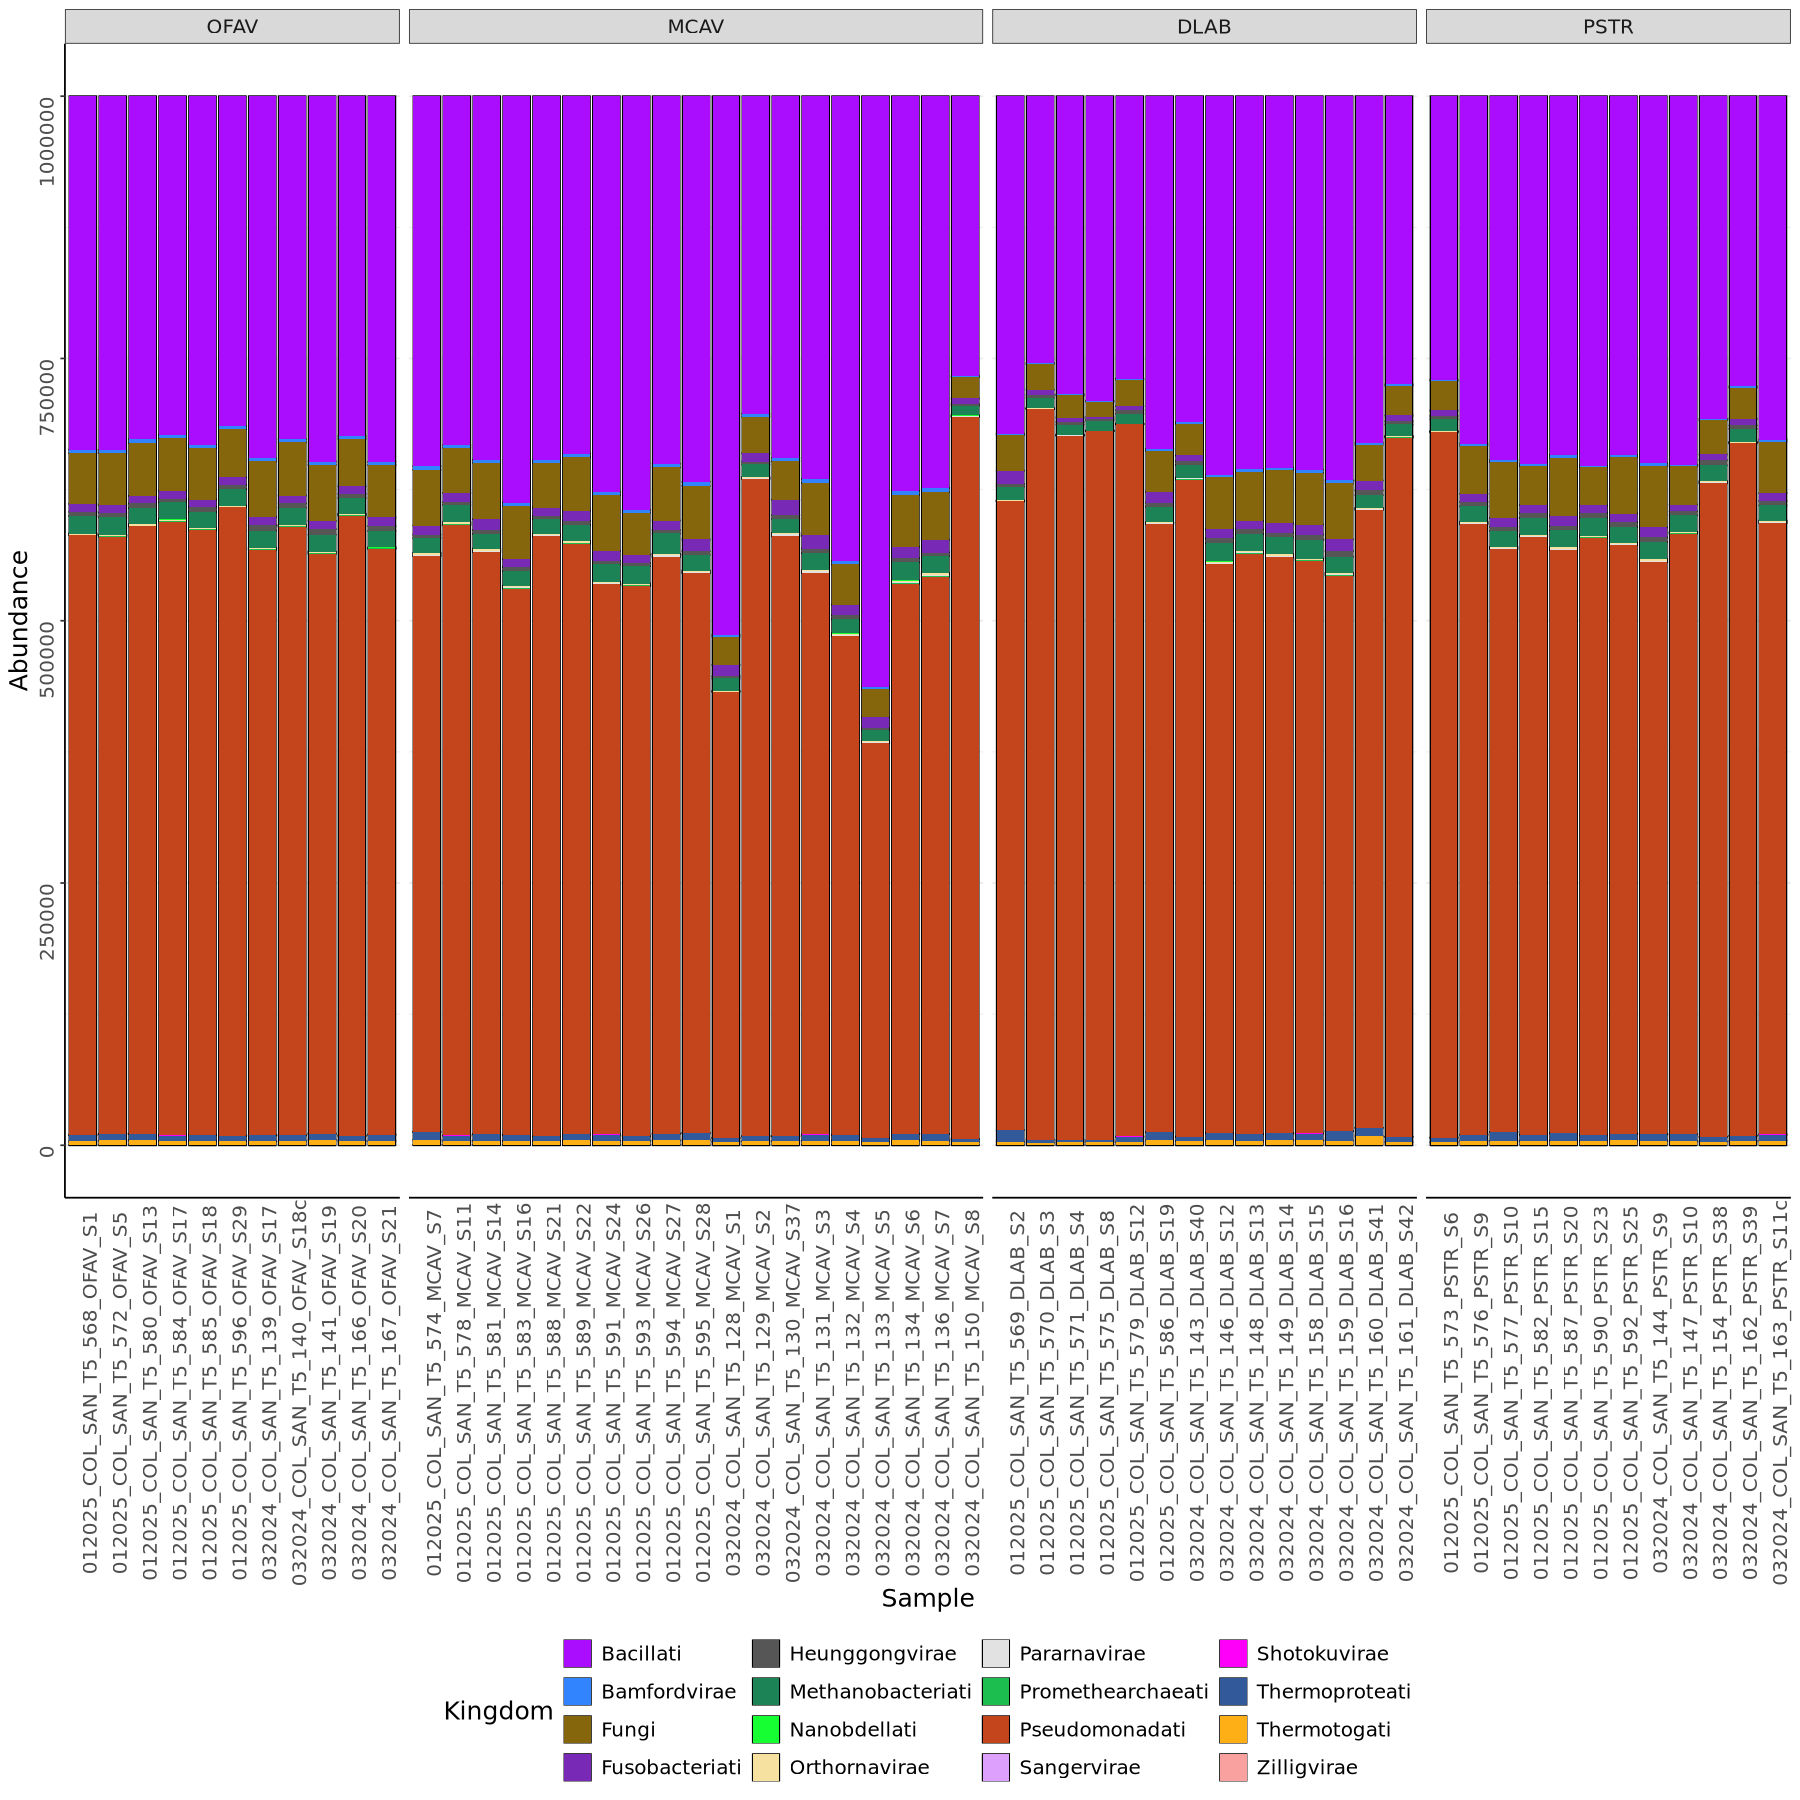

In [99]:
# bar plot of kingdoms IDed in all samples
COL_k_all_bar<-plot_bar(COL_k_all,fill='species')+
facet_grid(~Species_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_manual(values=unname(alphabet2())) +
theme_bw()+
labs(fill = "Kingdom")+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
COL_k_all_bar

In [100]:
#save with the hideous colors for now but find new palette pronto
ggsave(filename = "taxonomy_kingdoms.png", plot = COL_k_all_bar, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)